# BB84 vs CV-QKD: Headline Protocol Comparison

Generated from the public notebook builder for reproducible analysis.

Notebook 06 closes the project. No new physics modules are added; we combine everything from the earlier notebooks into a single headline figure that compares the BB84 and CV-QKD secure-key rates on the same axes under explicit, reproducible parameter sets.

## What this comparison can and cannot claim

* Both curves are *asymptotic* secure-key rates under stated parameter assumptions. **Finite-key effects are not included.**
* BB84 rates are reported **per emitted pulse**; CV-QKD rates are reported **per coherent-state symbol**. These are related channel-use normalisations &mdash; *not* a direct hardware throughput comparison.
* Cutoff distances and any "winner" language depend on the specific parameter set. Changing detector efficiency, excess noise, dark counts, or reconciliation efficiency changes the relative ordering.
* The defensible claim is that this repository implements and validates comparable DV/CV-QKD asymptotic models under stated assumptions; it does not claim that one protocol universally beats the other.

## Stated parameters

**BB84** (asymptotic simplified, idealised single-photon source):
* $\mu = 0.1$, $\eta_\mathrm{det} = 0.2$, $p_\mathrm{dark} = 10^{-6}$, $e_\mathrm{det} = 0$
* $f_\mathrm{ec} = 1.16$, $\alpha = 0.2$ dB/km
* rate normalisation: per emitted pulse

**CV-QKD GG02** (asymptotic collective Gaussian attack, untrusted-detector model):
* $V_A = 20$ shot-noise units, $\xi = 0.01$
* $\eta_\mathrm{det} = 0.6$, $\beta = 0.95$, $\alpha = 0.2$ dB/km
* rate normalisation: per coherent-state symbol

## 1. Bootstrap and imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator


In [2]:
import os

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from src.channel import (
    bb84_key_rate, fiber_transmittance, qber_channel,
)
from src.cvqkd import (
    cvqkd_holevo_bound_homodyne,
    cvqkd_key_rate,
    cvqkd_mutual_info_homodyne,
)
from src.info_theory import binary_entropy
from src.plotting import semilogy_positive

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

L = np.linspace(0.0, 300.0, 1001)


## 2. Compute both key-rate curves

These call the existing Notebook 03 / Notebook 04/05 implementations verbatim &mdash; the headline figure is just a combined result.

In [3]:
rate_bb84 = bb84_key_rate(L)
rate_cvqkd = cvqkd_key_rate(L)

print(f'BB84   K(0)   = {float(bb84_key_rate(0)):.6e} bits / pulse')
print(f'CV-QKD K(0)   = {float(cvqkd_key_rate(0)):.6e} bits / symbol')
print(f'BB84   K(50)  = {float(bb84_key_rate(50)):.6e} bits / pulse')
print(f'CV-QKD K(50)  = {float(cvqkd_key_rate(50)):.6e} bits / symbol')
print(f'BB84   K(150) = {float(bb84_key_rate(150)):.6e} bits / pulse')
print(f'CV-QKD K(150) = {float(cvqkd_key_rate(150)):.6e} bits / symbol')


BB84   K(0)   = 9.984011e-03 bits / pulse
CV-QKD K(0)   = 4.524346e-01 bits / symbol
BB84   K(50)  = 9.875977e-04 bits / pulse
CV-QKD K(50)  = 9.236829e-03 bits / symbol
BB84   K(150) = 4.661664e-06 bits / pulse
CV-QKD K(150) = 0.000000e+00 bits / symbol


## 3. Cutoff distances via Brent root-finding 

We find the cutoff by running `scipy.optimize.brentq` on the **unclamped** security expressions &mdash; $1 - h(E) - f_{ec}h(E)$ for BB84 and $\beta\,I(A:B) - \chi(B:E)$ for CV-QKD &mdash; **not** on the clamped key-rate curves, which lack a sign change.

Nothing in the table below is hard-coded.

In [4]:
def bb84_unclamped_privacy_bracket(
    L_km, mu=0.1, eta_det=0.2, p_dark=1e-6, e_det=0.0,
    f_ec=1.16, alpha_db_per_km=0.2,
):
    qber = qber_channel(
        L_km, mu=mu, eta_det=eta_det, p_dark=p_dark,
        alpha_dB=alpha_db_per_km, e_det=e_det,
    )
    return float(1.0 - binary_entropy(qber) - f_ec * binary_entropy(qber))


def cvqkd_unclamped_key_expression(
    L_km, V_A=20.0, xi=0.01, beta=0.95, eta_det=0.6,
    alpha_db_per_km=0.2,
):
    eta_ch = float(fiber_transmittance(L_km, alpha_dB=alpha_db_per_km))
    eta = eta_ch * eta_det
    if eta <= 0.0:
        return -np.inf
    I_AB = float(cvqkd_mutual_info_homodyne(V_A=V_A, eta=eta, xi=xi))
    chi_BE = float(cvqkd_holevo_bound_homodyne(V_A=V_A, eta=eta, xi=xi))
    return beta * I_AB - chi_BE


def cutoff_from_unclamped(expr, L_grid):
    vals = np.array([expr(float(l)) for l in L_grid])
    finite = np.isfinite(vals)
    if not np.any(finite):
        raise ValueError('No finite values in cutoff search')
    if np.all(vals[finite] > 0):
        return float(L_grid[-1])
    crossing = np.where(finite & (vals <= 0))[0]
    if len(crossing) == 0:
        raise ValueError('No finite zero crossing found')
    idx = int(crossing[0])
    if idx == 0:
        return float(L_grid[0])
    return brentq(expr, float(L_grid[idx - 1]), float(L_grid[idx]))


L_max_bb84 = cutoff_from_unclamped(bb84_unclamped_privacy_bracket, L)
L_max_cvqkd = cutoff_from_unclamped(cvqkd_unclamped_key_expression, L)

print(f'BB84   cutoff: {L_max_bb84:.2f} km')
print(f'CV-QKD cutoff: {L_max_cvqkd:.2f} km')


BB84   cutoff: 169.38 km
CV-QKD cutoff: 74.19 km


## 4. The headline comparison figure

* both curves on a `semilogy` axis with positive values masked,
* protocol-coloured vertical dashed lines at each cutoff,
* parameter text box listing all assumptions for both protocols,
* explicit security and normalisation labels,
* saved at 300 dpi to `figures/protocol_comparison.png` &mdash; the file the README embeds.

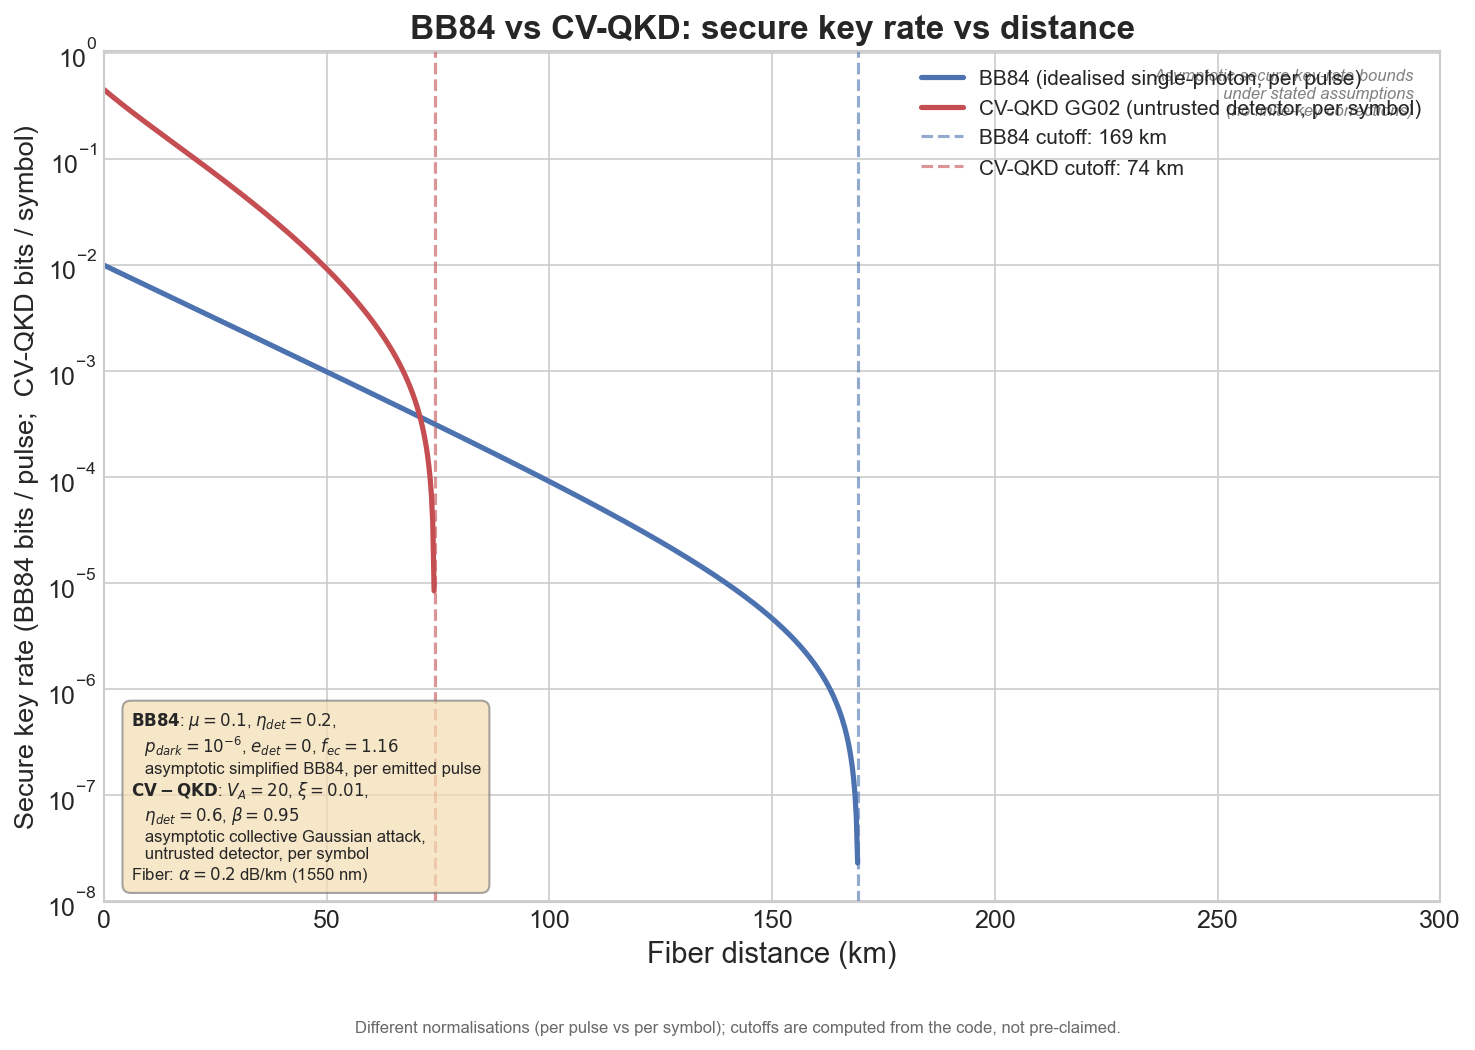

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

semilogy_positive(
    ax, L, rate_bb84, '-',
    color='#4C72B0', linewidth=2.5,
    label='BB84 (idealised single-photon, per pulse)',
)
semilogy_positive(
    ax, L, rate_cvqkd, '-',
    color='#C44E52', linewidth=2.5,
    label='CV-QKD GG02 (untrusted detector, per symbol)',
)

ax.axvline(L_max_bb84, color='#4C72B0', linestyle='--', alpha=0.6,
           label=f'BB84 cutoff: {L_max_bb84:.0f} km')
ax.axvline(L_max_cvqkd, color='#C44E52', linestyle='--', alpha=0.6,
           label=f'CV-QKD cutoff: {L_max_cvqkd:.0f} km')

ax.set_xlabel('Fiber distance (km)', fontsize=14)
ax.set_ylabel('Secure key rate (BB84 bits / pulse;  CV-QKD bits / symbol)',
              fontsize=13)
ax.set_title('BB84 vs CV-QKD: secure key rate vs distance',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 300)

bb84_text = (
    r'$\bf{BB84}$: $\mu = 0.1$, $\eta_{det} = 0.2$,'
    + '\n' + r'   $p_{dark} = 10^{-6}$, $e_{det} = 0$, $f_{ec} = 1.16$'
    + '\n' + r'   asymptotic simplified BB84, per emitted pulse'
)
cv_text = (
    r'$\bf{CV-QKD}$: $V_A = 20$, $\xi = 0.01$,'
    + '\n' + r'   $\eta_{det} = 0.6$, $\beta = 0.95$'
    + '\n' + r'   asymptotic collective Gaussian attack,'
    + '\n' + r'   untrusted detector, per symbol'
)
fiber_text = r'Fiber: $\alpha = 0.2$ dB/km (1550 nm)'
param_text = '\n'.join([bb84_text, cv_text, fiber_text])

ax.text(
    0.02, 0.02, param_text, transform=ax.transAxes, fontsize=8,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat',
              alpha=0.7, edgecolor='gray'),
)
ax.annotate(
    'Asymptotic secure key-rate bounds\n'
    'under stated assumptions\n'
    '(no finite-key corrections)',
    xy=(0.98, 0.98), xycoords='axes fraction',
    fontsize=8, ha='right', va='top', color='gray',
    fontstyle='italic',
)

fig.text(
    0.5, 0.005,
    'Different normalisations (per pulse vs per symbol); '
    'cutoffs are computed from the code, not pre-claimed.',
    ha='center', fontsize=8, color='dimgray',
)

plt.tight_layout(rect=(0.0, 0.04, 1.0, 1.0))
plt.savefig(FIG_DIR / 'protocol_comparison.png', dpi=300,
            bbox_inches='tight')
plt.show()


## 5. Computed summary table 

Every value below is computed by calling the implementations &mdash; no hard-coded numbers.

In [6]:
rate_targets = [0.0, 10.0, 50.0, 100.0, 150.0]

header = (
    f'{"Distance (km)":>14}'
    f'{"BB84 (bits / pulse)":>22}'
    f'{"CV-QKD (bits / symbol)":>26}'
)
print(header)
print('=' * len(header))
for d in rate_targets:
    r_bb = float(bb84_key_rate(d))
    r_cv = float(cvqkd_key_rate(d))
    print(f'{d:>14.1f}{r_bb:>22.6e}{r_cv:>26.6e}')
print()

print('Protocol summary table :')
print('=' * 110)
print(
    f'{"Protocol":<10}'
    f'{"Source / detector":<32}'
    f'{"Trust model":<22}'
    f'{"Cutoff (km)":>14}'
    f'{"K @ 50 km":>14}'
    f'  Security label'
)
print('-' * 110)
print(
    f'{"BB84":<10}'
    f'{"idealised single-photon source":<32}'
    f'{"-- (single-photon)":<22}'
    f'{L_max_bb84:>12.1f} km'
    f'{float(bb84_key_rate(50)):>14.4e}'
    f'  asymptotic simplified BB84'
)
print(
    f'{"CV-QKD":<10}'
    f'{"GG02 Gaussian modulation":<32}'
    f'{"untrusted detector":<22}'
    f'{L_max_cvqkd:>12.1f} km'
    f'{float(cvqkd_key_rate(50)):>14.4e}'
    f'  asymptotic collective Gaussian'
)
print('=' * 110)


 Distance (km)   BB84 (bits / pulse)    CV-QKD (bits / symbol)
           0.0          9.984011e-03              4.524346e-01
          10.0          6.294302e-03              2.119792e-01
          50.0          9.875977e-04              9.236829e-03
         100.0          9.117488e-05              0.000000e+00
         150.0          4.661664e-06              0.000000e+00

Protocol summary table :
Protocol  Source / detector               Trust model              Cutoff (km)     K @ 50 km  Security label
--------------------------------------------------------------------------------------------------------------
BB84      idealised single-photon source  -- (single-photon)           169.4 km    9.8760e-04  asymptotic simplified BB84
CV-QKD    GG02 Gaussian modulation        untrusted detector            74.2 km    9.2368e-03  asymptotic collective Gaussian


## 6. Practical-distance illustration

If a deployment needs (say) **1 kbit / s** of secret key, what is the longest fiber span each protocol can serve under these parameters? We pick illustrative channel-use rates for each &mdash; 1 GHz pulses for BB84 and 1 GHz coherent symbols for CV-QKD &mdash; convert the threshold rate to the protocol's natural unit, and root-find.

In [7]:
target_rate_bps = 1e3
bb84_pulse_rate_hz = 1e9
cv_symbol_rate_hz = 1e9

bb84_target_per_pulse = target_rate_bps / bb84_pulse_rate_hz
cv_target_per_symbol = target_rate_bps / cv_symbol_rate_hz


def find_distance_for_rate(rate_func, target, L_range=(0.0, 300.0)):
    def f(l):
        return float(rate_func(l)) - target
    if f(L_range[0]) < 0:
        return 0.0
    if f(L_range[1]) >= 0:
        return float(L_range[1])
    return float(brentq(f, L_range[0], L_range[1]))


L_target_bb84 = find_distance_for_rate(bb84_key_rate, bb84_target_per_pulse)
L_target_cv = find_distance_for_rate(cvqkd_key_rate, cv_target_per_symbol)

print(f'Target            : {target_rate_bps:.0f} bit / s')
print(f'BB84   threshold : {bb84_target_per_pulse:.1e} bits / pulse '
      f'at {bb84_pulse_rate_hz:.1e} pulses / s -> {L_target_bb84:.1f} km')
print(f'CV-QKD threshold : {cv_target_per_symbol:.1e} bits / symbol '
      f'at {cv_symbol_rate_hz:.1e} symbols / s -> {L_target_cv:.1f} km')


Target            : 1000 bit / s
BB84   threshold : 1.0e-06 bits / pulse at 1.0e+09 pulses / s -> 163.0 km
CV-QKD threshold : 1.0e-06 bits / symbol at 1.0e+09 symbols / s -> 74.2 km
